# 04. Normalization Test

This notebook checks coordinate normalization using a single comparison view.

Current method:

- translation reference: frame-wise hip center
- scale reference: sequence-wise median torso length

This notebook assumes that the previous checks are already working:

- 00_environment_check
- 01_data_loading_test
- 02_validation_test
- 03_raw_visualization_test

The goal here is to run normalization, check the normalization report, and compare raw and normalized coordinates in one visualization.


In [1]:
import json

from movement.io import load_pose_csv
from movement.config import LANDMARKS, CONNECTIONS
from movement.normalization import (
    normalize_pose_by_hip_torso,
    check_normalization_result,
)
from movement.visualization import create_pose_comparison_animation


In [2]:
csv_path = "../data/sample/mediapipe_forward_bend_sample.csv"

df = load_pose_csv(csv_path)

df.head()


,frame,timestamp,nose_x,nose_y,nose_z,nose_visibility,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_inner_visibility,...,right_heel_z,right_heel_visibility,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_visibility,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_visibility
0,0,0.000000,0.500000,0.220000,0.030000,0.98,0.482000,0.195000,0.030000,0.98,...,0.000000,0.98,0.420000,0.98,0.090000,0.98,0.580000,0.98,0.090000,0.98
1,1,0.033333,0.500290,0.220209,0.030503,0.98,0.482290,0.195209,0.030503,0.98,...,0.000169,0.98,0.420290,0.98,0.090169,0.98,0.580290,0.98,0.090169,0.98
2,2,0.066667,0.500579,0.220836,0.031674,0.98,0.482579,0.195836,0.031674,0.98,...,0.000338,0.98,0.420579,0.98,0.090338,0.98,0.580579,0.98,0.090338,0.98
3,3,0.100000,0.500867,0.221878,0.033510,0.98,0.482867,0.196878,0.033510,0.98,...,0.000506,0.98,0.420867,0.98,0.090506,0.98,0.580867,0.98,0.090506,0.98
4,4,0.133333,0.501151,0.223333,0.036005,0.98,0.483151,0.198333,0.036005,0.98,...,0.000673,0.98,0.421151,0.98,0.090673,0.98,0.581151,0.98,0.090673,0.98


In [3]:
norm_df, norm_report = normalize_pose_by_hip_torso(
    df=df,
    landmarks=LANDMARKS,
)

print(json.dumps(norm_report, indent=2, ensure_ascii=False))


{
  "method": "hip_centered_sequence_median_torso_scale",
  "num_frames": 120,
  "num_normalized_landmarks": 33,
  "normalized_columns": [
    "nose_norm_x",
    "nose_norm_y",
    "nose_norm_z",
    "left_eye_inner_norm_x",
    "left_eye_inner_norm_y",
    "left_eye_inner_norm_z",
    "left_eye_norm_x",
    "left_eye_norm_y",
    "left_eye_norm_z",
    "left_eye_outer_norm_x",
    "left_eye_outer_norm_y",
    "left_eye_outer_norm_z",
    "right_eye_inner_norm_x",
    "right_eye_inner_norm_y",
    "right_eye_inner_norm_z",
    "right_eye_norm_x",
    "right_eye_norm_y",
    "right_eye_norm_z",
    "right_eye_outer_norm_x",
    "right_eye_outer_norm_y",
    "right_eye_outer_norm_z",
    "left_ear_norm_x",
    "left_ear_norm_y",
    "left_ear_norm_z",
    "right_ear_norm_x",
    "right_ear_norm_y",
    "right_ear_norm_z",
    "mouth_left_norm_x",
    "mouth_left_norm_y",
    "mouth_left_norm_z",
    "mouth_right_norm_x",
    "mouth_right_norm_y",
    "mouth_right_norm_z",
    "left_shoul

In [4]:
check_report = check_normalization_result(norm_df)

print(json.dumps(check_report, indent=2, ensure_ascii=False))


{
  "passed": true,
  "max_abs_hip_center": 2.220446049250313e-16,
  "median_normalized_torso_length": 1.0,
  "min_normalized_torso_length": 0.8687428083759277,
  "max_normalized_torso_length": 1.3984227940656926
}


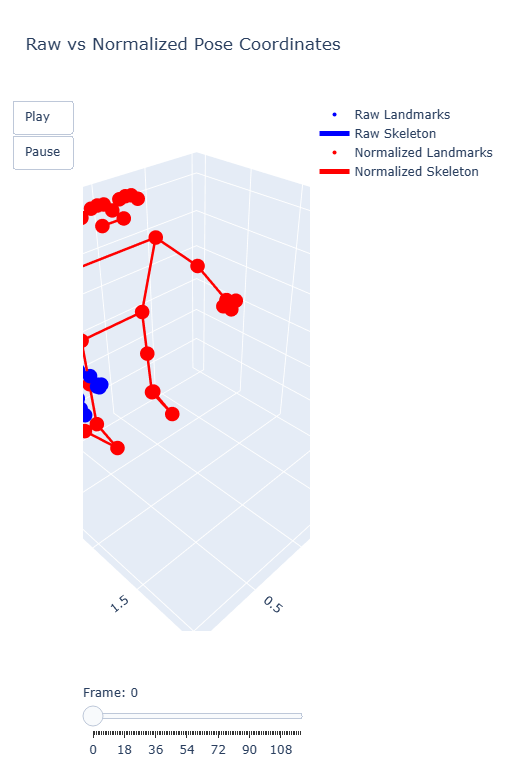

In [5]:
fig_compare = create_pose_comparison_animation(
    df=norm_df,
    landmarks=LANDMARKS,
    connections=CONNECTIONS,
    coord_modes=("raw", "norm"),
    names=("Raw", "Normalized"),
    title="Raw vs Normalized Pose Coordinates",
    show_text=False,
)

fig_compare.show()


## Interpretation

The raw and normalized skeletons may appear in different positions because they use different coordinate systems.

- Raw coordinates use the original pose/model coordinate space.
- Normalized coordinates use a hip-centered and torso-scaled coordinate space.

The comparison view is mainly for debugging whether both coordinate modes are available and whether the normalized skeleton behaves consistently.

Expected checks:

- `check_report["passed"]` should be `True`
- normalized hip center should be approximately zero
- median normalized torso length should be approximately 1.0
